In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [9]:
(df['y'].value_counts(normalize=True)*100).round(2)

,proportion
y,
no,88.3
yes,11.7


In [10]:
total_contacts = len(df)

converted = len(df[df['y'] == 'yes'])

not_converted = len(df[df['y'] == 'no'])

conversion_rate = round((converted / total_contacts) * 100, 2)

print("Total Contacts:", total_contacts)
print("Converted Customers:", converted)
print("Not Converted:", not_converted)
print("Conversion Rate:", conversion_rate, "%")

Total Contacts: 45211
Converted Customers: 5289
Not Converted: 39922
Conversion Rate: 11.7 %


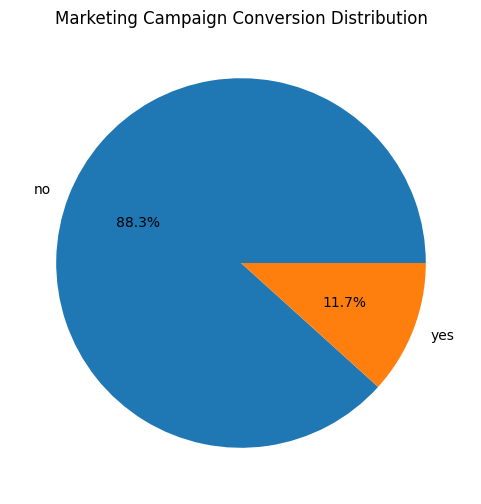

In [11]:
plt.figure(figsize=(6,6))

df['y'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Marketing Campaign Conversion Distribution')
plt.ylabel('')
plt.show()

In [12]:
channel_conv = pd.crosstab(df['contact'], df['y'])

channel_conv

y,no,yes
contact,,
cellular,24916,4369
telephone,2516,390
unknown,12490,530


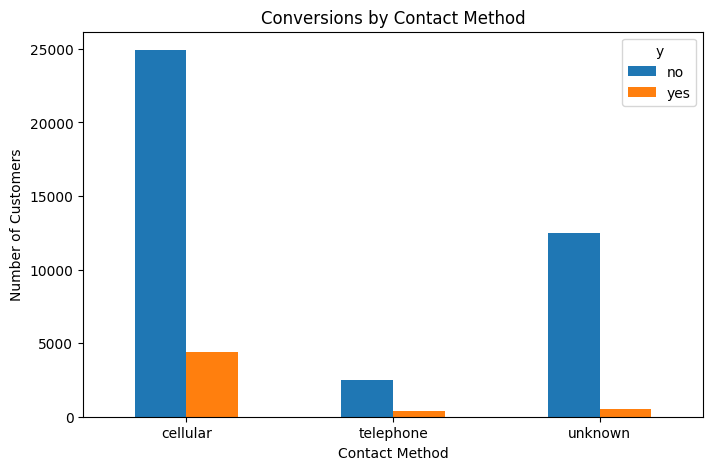

In [13]:
channel_conv.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Conversions by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

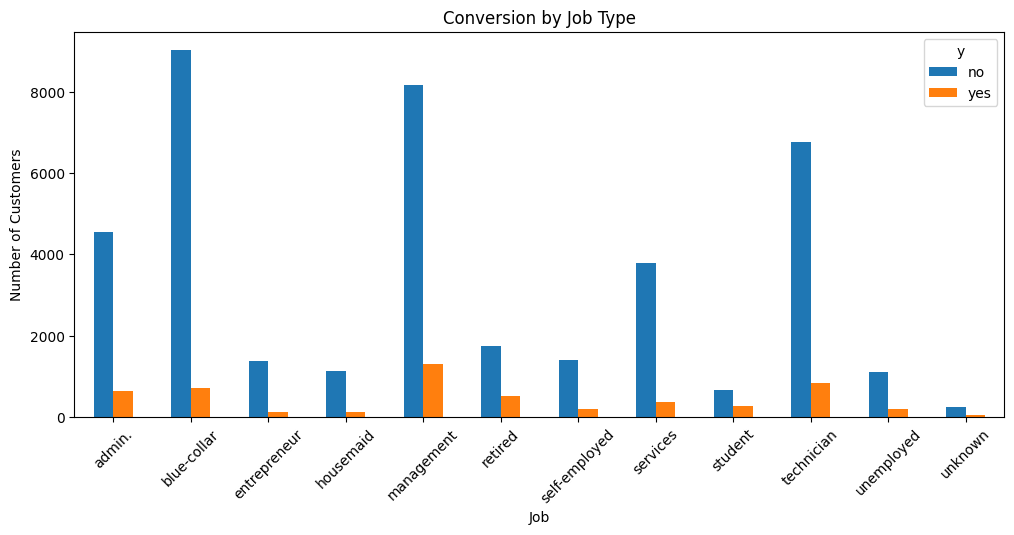

In [14]:
job_conv = pd.crosstab(df['job'], df['y'])

job_conv.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Conversion by Job Type')
plt.xlabel('Job')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [15]:
channel_rate = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

channel_rate.round(2)

y,no,yes
contact,,
cellular,85.08,14.92
telephone,86.58,13.42
unknown,95.93,4.07


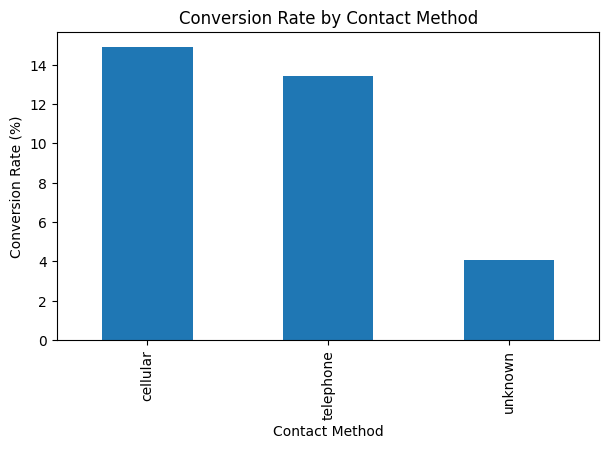

In [16]:
channel_rate['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Conversion Rate by Contact Method')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Contact Method')
plt.show()

In [17]:
job_rate = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_rate.round(2)

y,no,yes
job,,
admin.,87.80,12.20
blue-collar,92.73,7.27
entrepreneur,91.73,8.27
housemaid,91.21,8.79
management,86.24,13.76
retired,77.21,22.79
self-employed,88.16,11.84
services,91.12,8.88
student,71.32,28.68


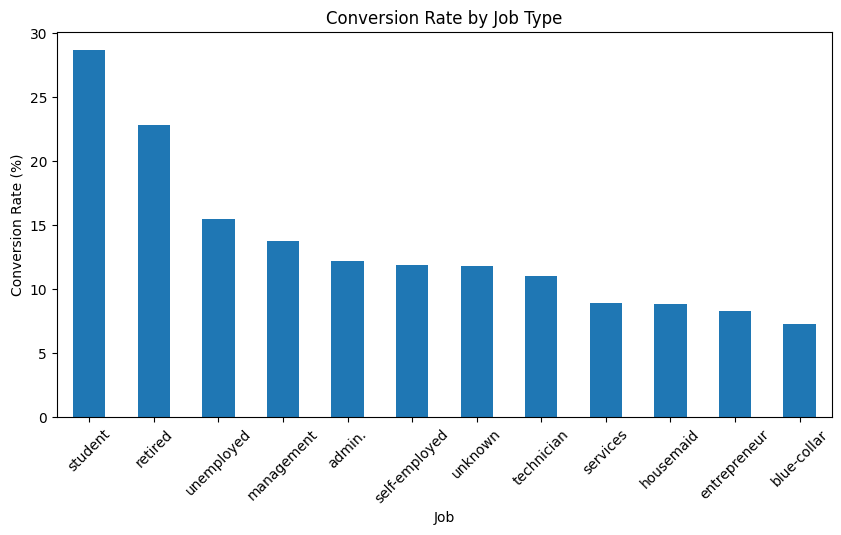

In [18]:
job_rate['yes'].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Conversion Rate by Job Type')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Job')
plt.xticks(rotation=45)
plt.show()

In [19]:
df['Age_Group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

In [20]:
age_rate = pd.crosstab(
    df['Age_Group'],
    df['y'],
    normalize='index'
) * 100

age_rate.round(2)

y,no,yes
Age_Group,,
18-30,83.78,16.22
31-40,89.76,10.24
41-50,90.93,9.07
51-60,89.95,10.05
60+,57.74,42.26


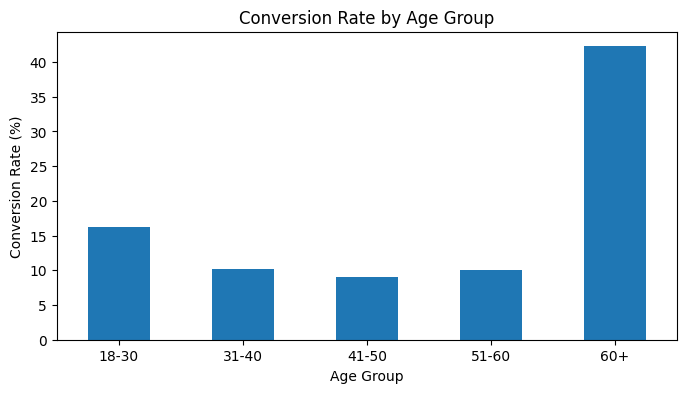

In [21]:
age_rate['yes'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Conversion Rate by Age Group')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.show()

In [22]:
funnel = pd.DataFrame({
    'Stage': [
        'Total Contacts',
        'Successful Contacts',
        'Previous Engagement',
        'Converted Customers'
    ],
    'Count': [
        len(df),
        len(df[df['duration'] > 0]),
        len(df[df['previous'] > 0]),
        len(df[df['y'] == 'yes'])
    ]
})

funnel

,Stage,Count
0,Total Contacts,45211
1,Successful Contacts,45208
2,Previous Engagement,8257
3,Converted Customers,5289


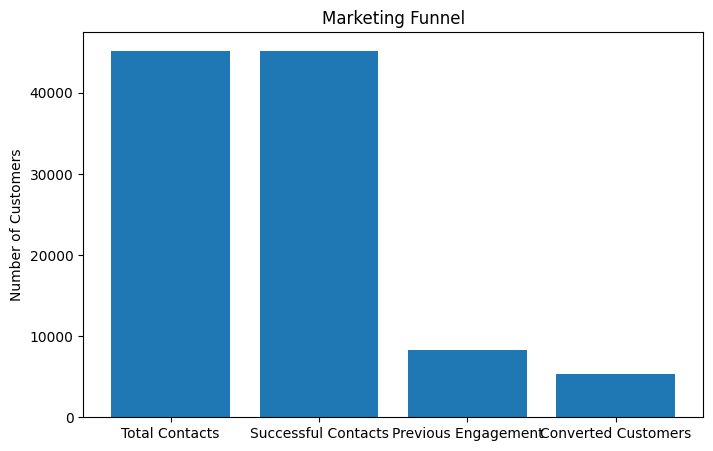

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    funnel['Stage'],
    funnel['Count']
)

plt.title('Marketing Funnel')
plt.ylabel('Number of Customers')
plt.show()

In [24]:
campaign_conv = pd.crosstab(
    df['campaign'],
    df['y']
)

campaign_conv.head()

y,no,yes
campaign,,
1,14983,2561
2,11104,1401
3,4903,618
4,3205,317
5,1625,139


In [25]:
campaign_rate = pd.crosstab(
    df['campaign'],
    df['y'],
    normalize='index'
) * 100

campaign_rate['yes'].head(15)

,yes
campaign,
1,14.597583
2,11.203519
3,11.193624
4,9.000568
5,7.879819
6,7.126259
7,6.394558
8,5.925926
9,6.422018


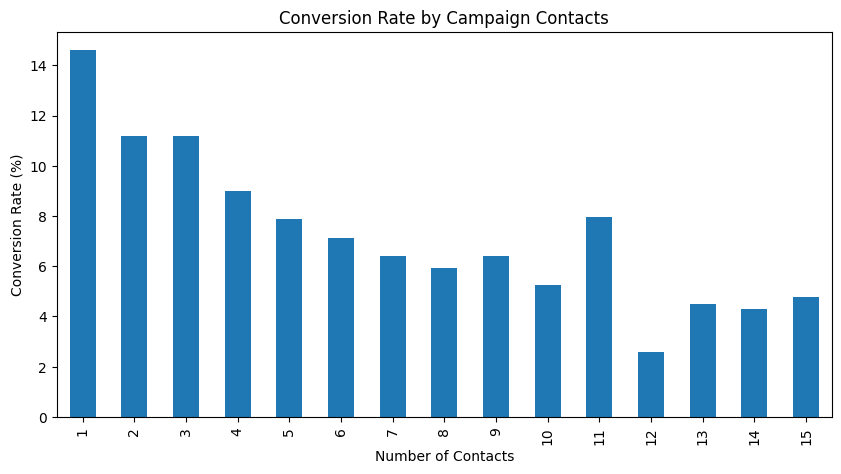

In [28]:
campaign_rate['yes'].head(15).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Conversion Rate by Campaign Contacts')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Number of Contacts')
plt.show()

In [29]:
month_rate = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
) * 100

month_rate

y,no,yes
month,,
apr,80.320600,19.679400
aug,88.986714,11.013286
dec,53.271028,46.728972
feb,83.352208,16.647792
jan,89.878831,10.121169
jul,90.906454,9.093546
jun,89.777195,10.222805
mar,48.008386,51.991614
may,93.280546,6.719454


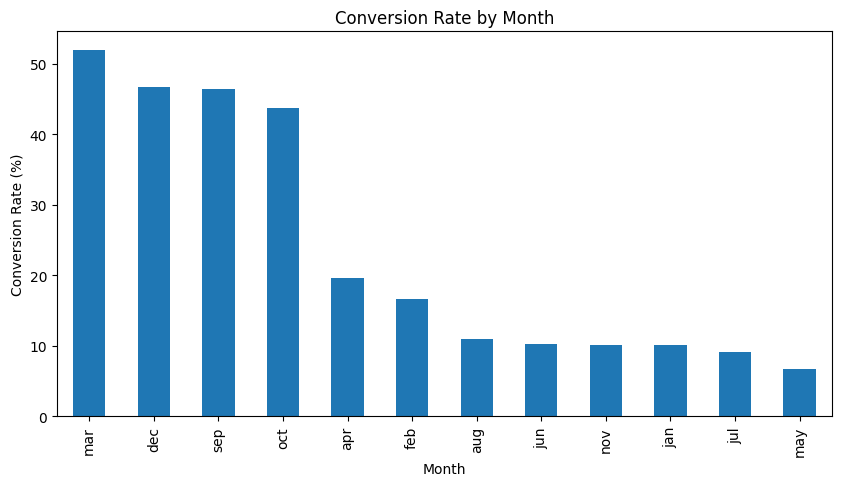

In [30]:
month_rate['yes'].sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Conversion Rate by Month')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Month')
plt.show()

In [31]:
df.to_csv(
    'marketing_funnel_cleaned.csv',
    index=False
)

print("Dataset Exported Successfully")

Dataset Exported Successfully
